In [107]:
# Import necessary libraries
import numpy as np      #Numerical Python
import pandas as pd     
import matplotlib.pyplot as plt  #used for graphs. beautiful graphs with less code.
import seaborn as sns #another graph library.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder #This imports preprocessing tools.Preprocessing means Cleaning data before Machine Learning.
from sklearn.impute import SimpleImputer #SimpleImputer fills missing values using strategies like mean, median, or most frequent value.
from sklearn.compose import ColumnTransformer #ColumnTransformer applies the correct operation to each column automatically.
from sklearn.pipeline import Pipeline #A pipeline connects all preprocessing steps.
from sklearn.ensemble import RandomForestClassifier  #A Random Forest is a Machine Learning algorithm.It creates many decision trees.Then all trees vote.Whichever answer gets the most votes becomes the prediction.
from sklearn.linear_model import LogisticRegression #Despite its name, it is mainly used for classification, such as predicting
from sklearn.metrics import accuracy_score, classification_report

In [108]:

# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)


In [109]:

# Exploring missing values
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

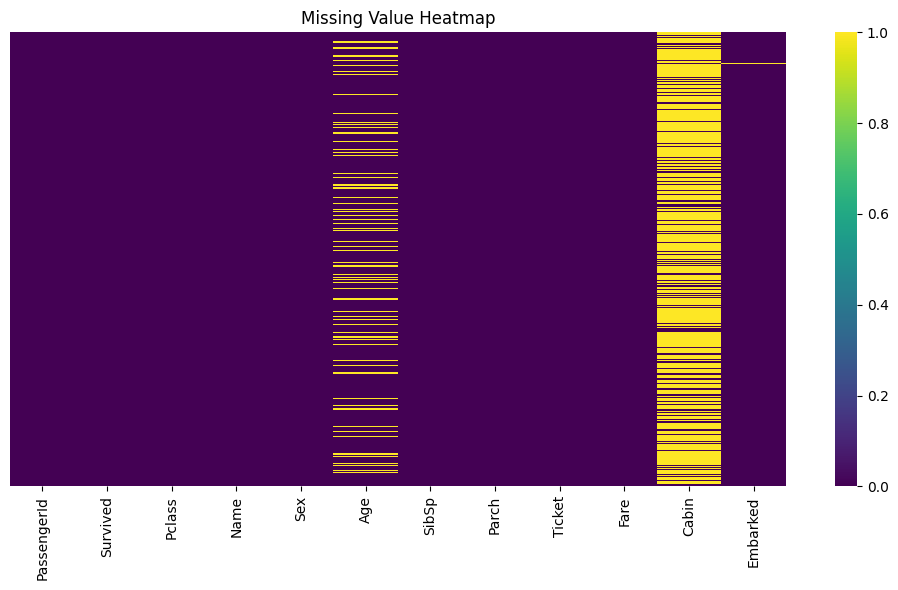

In [110]:

# Visualize missing values
plt.figure(figsize=(10, 6)) #creates a figure 10 inches wide and 6 inches tall.
sns.heatmap(titanic.isnull(), cbar=True, yticklabels=False, cmap='viridis') #yticklabels=hides row labels
plt.title('Missing Value Heatmap')
plt.tight_layout() #adjusts spacing so nothing overlaps.
plt.show()

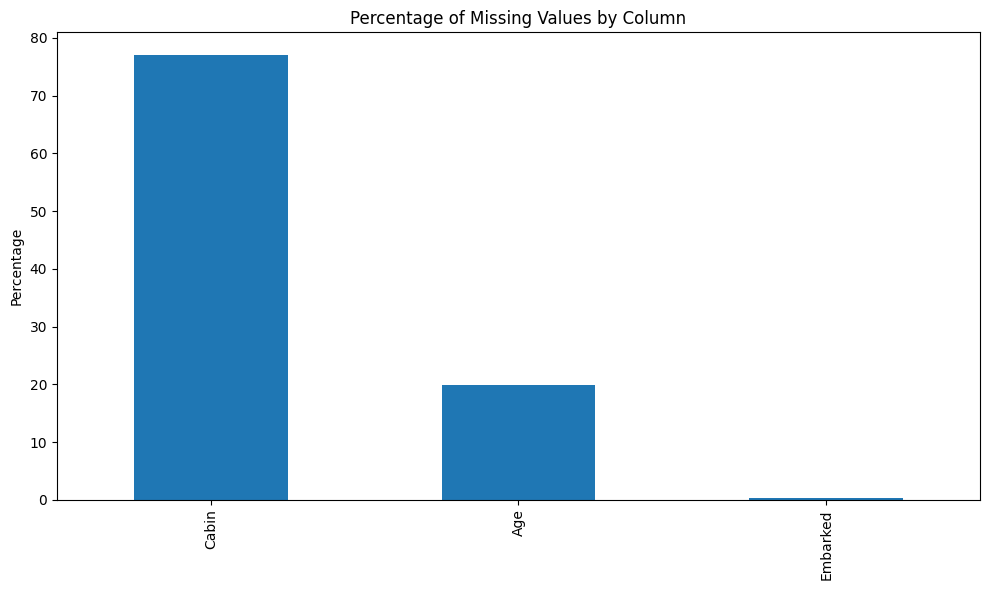

In [111]:
# Calculate percentage of missing values per column
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.tight_layout() #adjusts spacing so nothing overlaps.
plt.show()

# HANDLING MISSING VALUES

In [112]:
# 1. Deletion approach - not always recommended but useful for some columns
titanic_reduced = titanic.drop(['Cabin', 'Ticket'], axis=1)  # High missingness or less relevant

In [113]:
# 2. Simple imputation for Age (using median grouped by Pclass)
age_imputed = titanic_reduced.copy()
age_imputed['Age'] = age_imputed.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [114]:

# 3. Create missing indicator for Age
age_imputed['Age_Missing'] = titanic_reduced['Age'].isnull().astype(int)

In [115]:
# 4. Mode imputation for categorical column (Embarked)
age_imputed['Embarked'] = age_imputed['Embarked'].fillna(age_imputed['Embarked'].mode()[0])

In [116]:
# Verify imputation results
age_imputed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

Text(0.5, 1.0, 'Original Age Distribution')

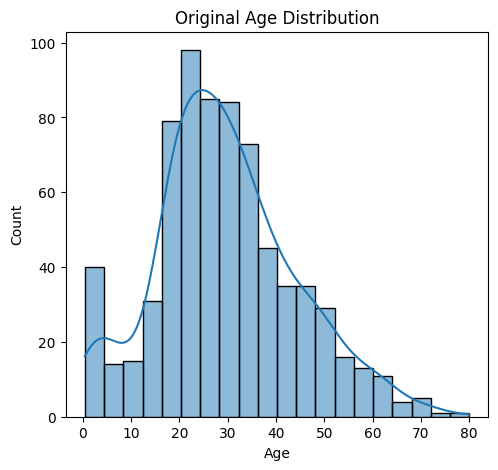

In [117]:
# Visualize Age distribution before and after imputation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(titanic['Age'].dropna(), kde=True)
plt.title('Original Age Distribution')


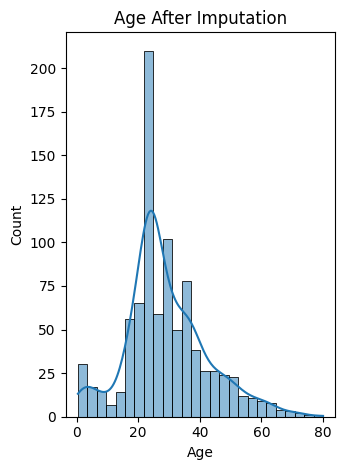

In [118]:
plt.subplot(1, 2, 2)
sns.histplot(age_imputed['Age'], kde=True)
plt.title('Age After Imputation')
plt.tight_layout()
plt.show()

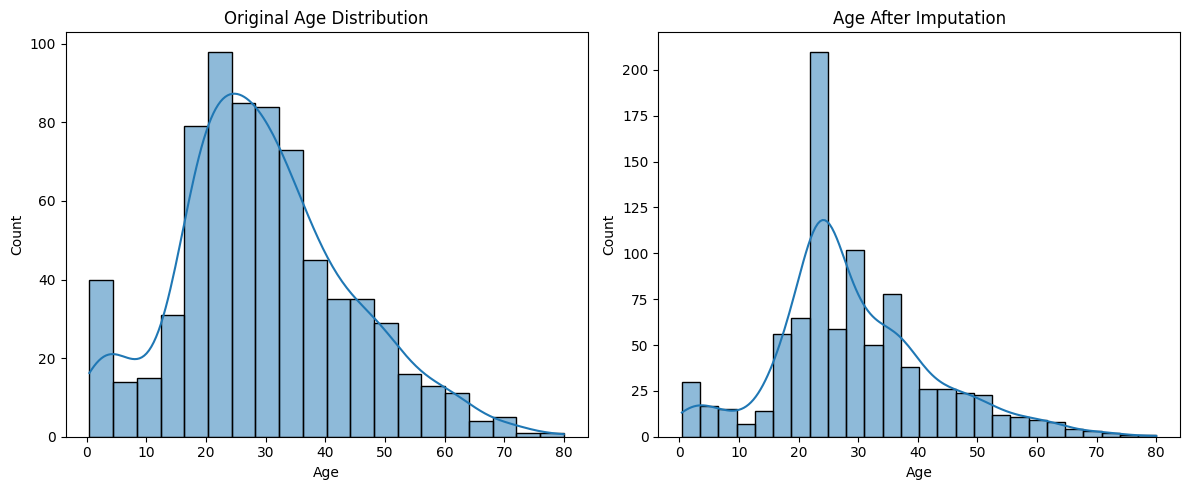

In [119]:
# Visualize Age distribution before and after imputation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(titanic['Age'].dropna(), kde=True)
plt.title('Original Age Distribution')

plt.subplot(1, 2, 2)
sns.histplot(age_imputed['Age'], kde=True)
plt.title('Age After Imputation')
plt.tight_layout()
plt.show()

# FEATURE SCALING

In [120]:
# Select relevant columns and prepare a dataset for ML
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'
X = age_imputed[features]
y = age_imputed[target]

In [121]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [122]:
# 1. Standardization (z-score normalization)
scaler = StandardScaler()
# Never directly transform your entire dataset - only fit on training data
numeric_features = ['Age', 'Fare']
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_std[numeric_features] = scaler.transform(X_test[numeric_features])

In [123]:
# 2. Min-Max Scaling (normalization)
min_max_scaler = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[numeric_features] = min_max_scaler.fit_transform(X_train[numeric_features])
X_test_norm[numeric_features] = min_max_scaler.transform(X_test[numeric_features])

Text(0.5, 1.0, 'Original Fare Distribution')

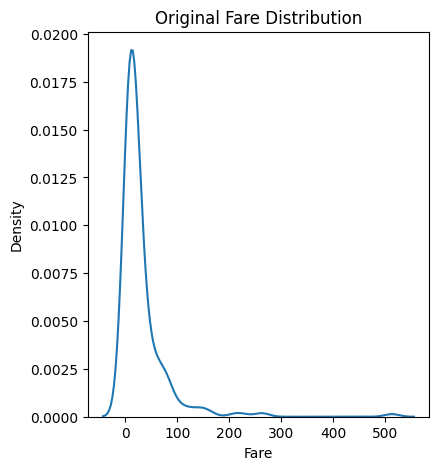

In [124]:
# Visualize scaling effects
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original')
plt.title('Original Fare Distribution')

Text(0.5, 1.0, 'Standardized Fare')

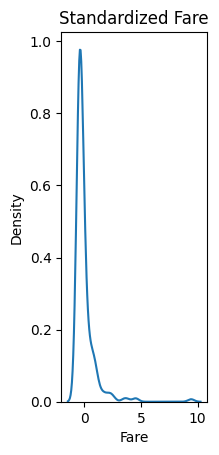

In [125]:
plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized')
plt.title('Standardized Fare')

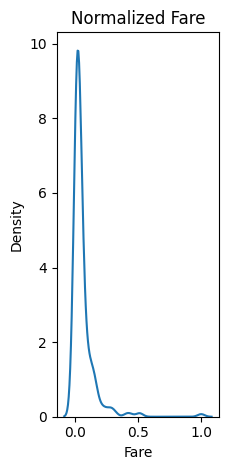

In [126]:
plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized')
plt.title('Normalized Fare')
plt.tight_layout()
plt.show()

# ENCODING CATEGORICAL VARIABLES

In [127]:
# 1. Label Encoding for ordinal features
label_encoder = LabelEncoder()
X_train_encoded = X_train_std.copy()
X_test_encoded = X_test_std.copy()

In [128]:
# Apply label encoding for Sex column
X_train_encoded['Sex'] = label_encoder.fit_transform(X_train_encoded['Sex'])
X_test_encoded['Sex'] = label_encoder.transform(X_test_encoded['Sex'])

In [129]:

# 2. One-Hot Encoding for nominal features
# Creating a one-hot encoder for 'Embarked'
embarked_ohe = OneHotEncoder(sparse_output=False, drop='first')
# Fit on training data
embarked_train_encoded = embarked_ohe.fit_transform(X_train_encoded[['Embarked']])
embarked_test_encoded = embarked_ohe.transform(X_test_encoded[['Embarked']])

In [130]:
# Create dataframes with the encoded columns
embarked_train_df = pd.DataFrame(
    embarked_train_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_train_encoded.index
)
embarked_test_df = pd.DataFrame(
    embarked_test_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_test_encoded.index
)

In [131]:

# Drop original Embarked column and join encoded columns
X_train_encoded = X_train_encoded.drop('Embarked', axis=1).join(embarked_train_df)
X_test_encoded = X_test_encoded.drop('Embarked', axis=1).join(embarked_test_df)


In [132]:
# Compare encoding methods
print("Label Encoded 'Sex':")
print(X_train_encoded['Sex'].value_counts())

Label Encoded 'Sex':
Sex
1    410
0    213
Name: count, dtype: int64


In [133]:
print("\nOne-Hot Encoded 'Embarked':")
print(X_train_encoded.filter(like='Embarked').head())


One-Hot Encoded 'Embarked':
     Embarked_Q  Embarked_S
445         0.0         1.0
650         0.0         1.0
172         0.0         1.0
450         0.0         1.0
314         0.0         1.0


# BUILDING PREPROCESSING PIPELINES

In [134]:
# Define preprocessing for numerical columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [135]:
# Define preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

In [136]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_features),
        ('cat', categorical_transformer, ['Sex', 'Embarked'])
    ])


In [137]:
# Create a full pipeline with preprocessing and model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [138]:
# Reset to use raw features for complete pipeline demonstration
X = age_imputed[features]
y = age_imputed[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [139]:
# Train the pipeline
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [140]:
# Make predictions
predictions = model_pipeline.predict(X_test)

In [141]:
# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.7799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



# ADVANCED: Custom Pipeline with Cross-Validation

In [142]:
from sklearn.model_selection import GridSearchCV

# Create a pipeline with multiple possible models
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [143]:
# Define parameters to search
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10],
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
}

In [144]:
# Set up GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5,
                          scoring='accuracy', n_jobs=-1)

In [145]:
# Fit the grid search
grid_search.fit(X_train, y_train)


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__max_depth': [None, 10], 'classifier__n_estimators': [50, 100], 'preprocessor__num__imputer__strategy': ['mean', 'median']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [146]:
# Best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'preprocessor__num__imputer__strategy': 'mean'}
Best cross-validation score: 0.7979


In [147]:
# Evaluate on test set
test_score = grid_search.score(X_test, y_test)
print(f"Test set score with best parameters: {test_score:.4f}")

Test set score with best parameters: 0.7612


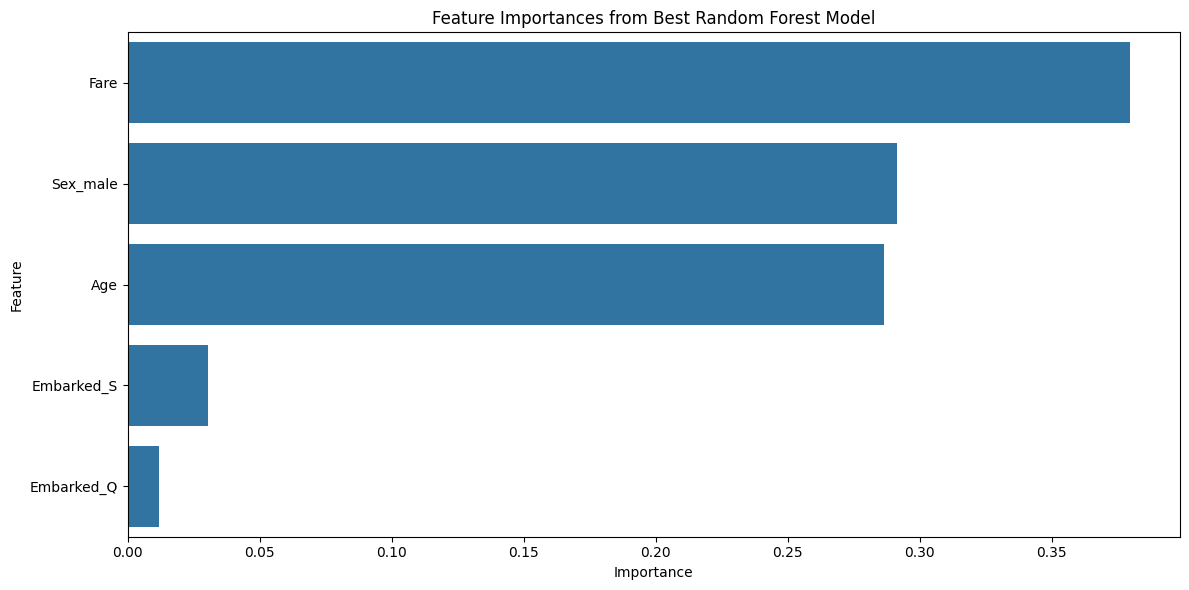

In [148]:
# BONUS: Feature importance from the best model
if hasattr(grid_search.best_estimator_.named_steps['classifier'], 'feature_importances_'):
    # Get the preprocessor
    preprocessor = grid_search.best_estimator_.named_steps['preprocessor']

    # Get the feature names after transformation
    ohe_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
    feature_names = np.concatenate([numeric_features, ohe_features])

    # Get feature importances
    importances = grid_search.best_estimator_.named_steps['classifier'].feature_importances_

    # Create a DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Plot feature importances
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importances from Best Random Forest Model')
    plt.tight_layout()
    plt.show()

# Excercise

# Week 3 Day 1: Titanic Data Preprocessing & Modeling

In this exercise you'll reinforce:

- **Missing‑value exploration & visualization**  
- **Imputation strategies** (deletion, group‑median, mode, missing indicator)  
- **Feature scaling** (StandardScaler vs MinMaxScaler)  
- **Categorical encoding** (LabelEncoder, OneHotEncoder)  
- **Building end‑to‑end pipelines** with `ColumnTransformer` + `Pipeline`  
- **Model training & evaluation** (LogisticRegression, RandomForest)  
- **Hyperparameter tuning** via `GridSearchCV`  
- **Feature importance** extraction  

> **Instructions:**  
> 1. Don’t modify cells above the first `# TODO`.  
> 2. Replace each `# TODO` with your code.  
> 3. Run cells sequentially and verify each output.  
> 4. Wherever requested, add a brief comment on what you observe.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


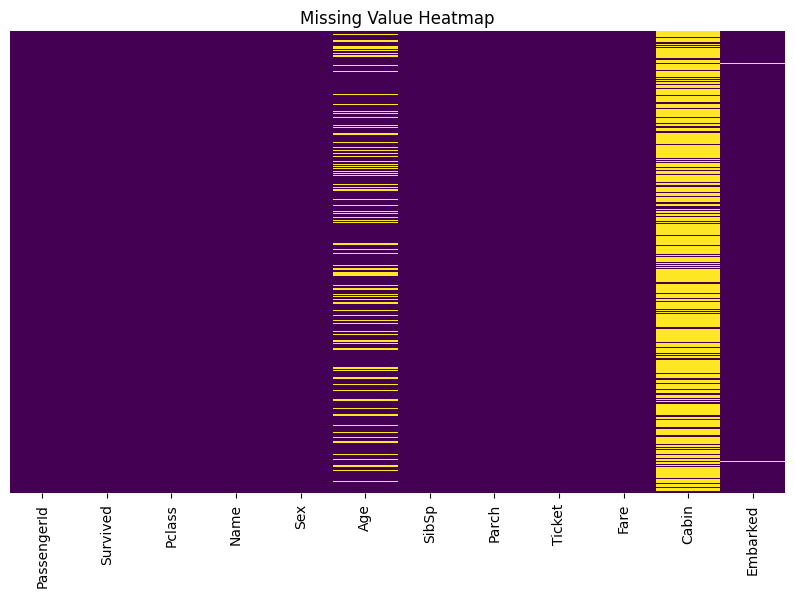

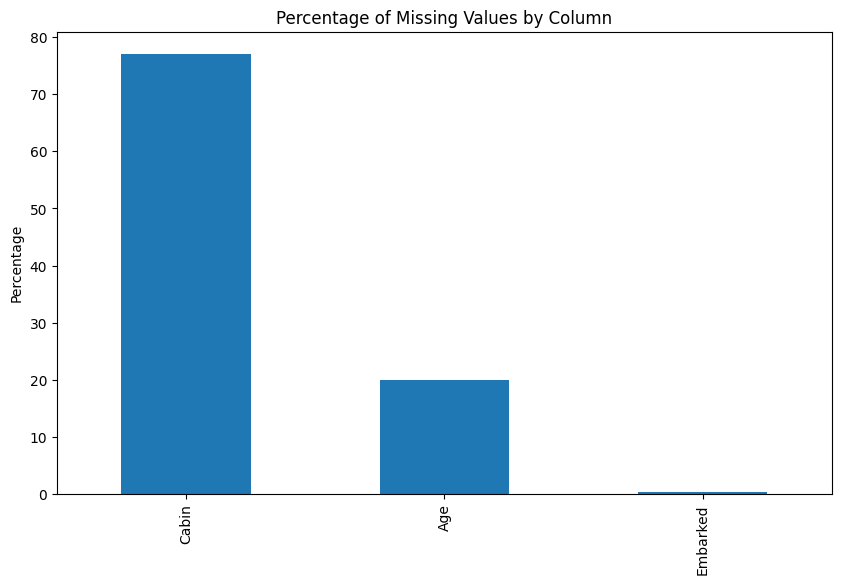

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.1 Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# 1.2 How many missing values per column?
# TODO: Compute and display titanic.isnull().sum()
print(titanic.isnull().sum())

# 1.3 Visualize missingness with a heatmap
plt.figure(figsize=(10,6))

# TODO: use sns.heatmap(...) to show where data is missing
sns.heatmap(
    titanic.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Value Heatmap")
plt.show()

# 1.4 Percentage of missing values by column (bar plot)
# TODO: calculate percentage and plot as a bar chart

missing_percentage = titanic.isnull().mean() * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

plt.figure(figsize=(10,6))

missing_percentage.plot(kind='bar')

plt.title("Percentage of Missing Values by Column")

plt.ylabel("Percentage")

plt.show()


2- Handle Missing Values ---

In [150]:
# Start from a copy
df = titanic.copy()

# 2.1 Drop columns with too many missing or irrelevant
# TODO: df = df.drop([...], axis=1)
df = df.drop(['Cabin', 'Ticket'], axis=1)

# 2.2 Impute Age by median within each Pclass
# TODO: df['Age'] = df.groupby('Pclass')['Age'].transform(...)
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 2.3 Create Age_missing indicator column
# TODO: df['Age_Missing'] = ...
df['Age_Missing'] = titanic['Age'].isnull().astype(int)


# 2.4 Impute Embarked with mode
# TODO: df['Embarked'] = df['Embarked'].fillna(...)
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

# 2.5 Verify no more missing values
# TODO: df.isnull().sum()
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64


3. Feature Scaling

Standardized Training Data:
[[-1.86304525  0.98099823]
 [-0.35114837 -0.46963364]
 [-2.08982979 -0.40613632]
 [ 0.55598977 -0.08023177]
 [ 1.08515368 -0.10965138]]

Min-Max Scaled Training Data:
[[0.04498618 0.15977676]
 [0.2963056  0.01541158]
 [0.00728826 0.02173075]
 [0.44709726 0.05416439]
 [0.53505906 0.05123659]]


<Figure size 1500x500 with 0 Axes>

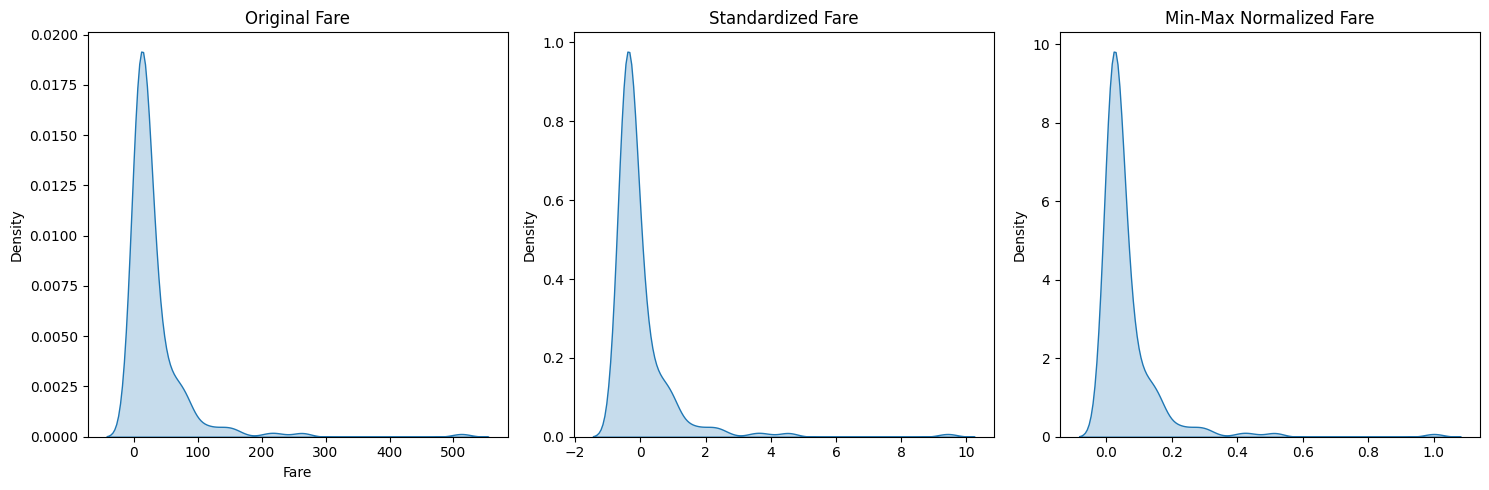

In [151]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

features = ['Age','Fare']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3.1 Standardization
std = StandardScaler()
# TODO: fit on X_train, transform both X_train and X_test

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

print("Standardized Training Data:")
print(X_train_std[:5])


# 3.2 Min‑Max normalization
mms = MinMaxScaler()
# TODO: fit on X_train, transform both X_train and X_test
X_train_mms = mms.fit_transform(X_train)
X_test_mms = mms.transform(X_test)

print("\nMin-Max Scaled Training Data:")
print(X_train_mms[:5])

# 3.3 Plot distributions: original vs standardized vs normalized
plt.figure(figsize=(15,5))
# TODO: three subplots with sns.kdeplot for Fare in each dataset

plt.figure(figsize=(15,5))

# Original Fare
plt.subplot(1,3,1)
sns.kdeplot(X_train['Fare'], fill=True)
plt.title("Original Fare")

# Standardized Fare
plt.subplot(1,3,2)
sns.kdeplot(X_train_std[:, X_train.columns.get_loc('Fare')], fill=True)
plt.title("Standardized Fare")

# Min-Max Normalized Fare
plt.subplot(1,3,3)
sns.kdeplot(X_train_mms[:, X_train.columns.get_loc('Fare')], fill=True)
plt.title("Min-Max Normalized Fare")

plt.tight_layout()
plt.show()

4. Encode Categorical Features

In [152]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

X_cat = df[['Sex','Embarked']]

# 4.1 Label‑encode Sex
le = LabelEncoder()
# TODO: X_cat['Sex_le'] = ...

le = LabelEncoder()
X_cat['Sex_le'] = le.fit_transform(X_cat['Sex'])


# 4.2 One‑hot encode Embarked (drop first)
ohe = OneHotEncoder(sparse_output=False, drop='first')
# TODO: fit_transform Embarked and create a DataFrame with new columns

ohe = OneHotEncoder(sparse_output=False, drop='first')

embarked_encoded = ohe.fit_transform(X_cat[['Embarked']])

embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=ohe.get_feature_names_out(['Embarked']),
    index=X_cat.index
)

result = pd.concat(
    [X_cat, embarked_df],
    axis=1
)

# Display your encoded features
# TODO: print head of resulting DataFrame
print(result.head())

      Sex Embarked  Sex_le  Embarked_Q  Embarked_S
0    male        S       1         0.0         1.0
1  female        C       0         0.0         0.0
2  female        S       0         0.0         1.0
3  female        S       0         0.0         1.0
4    male        S       1         0.0         1.0


C:\Users\binta\AppData\Local\Temp\ipykernel_11564\2445140068.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_cat['Sex_le'] = le.fit_transform(X_cat['Sex'])


5. Build a Preprocessing + Model Pipeline



In [153]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 5.1 Define transformers
num_features = ['Age','Fare']
cat_features = ['Sex','Embarked']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# 5.2 Create full pipeline with Logistic Regression
pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

# 5.3 Split raw data and train
X_full = df[num_features + cat_features]
y_full = df['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# TODO: fit pipe on X_tr, y_tr
# TODO: predict on X_te, compute accuracy and print classification_report

# Train the pipeline
pipe.fit(X_tr, y_tr)

# Predict
y_pred = pipe.predict(X_te)

# Accuracy
acc = accuracy_score(y_te, y_pred)

print("Accuracy:", acc)

print("\nClassification Report")

print(classification_report(y_te, y_pred))

Accuracy: 0.7798507462686567

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



6. Hyperparameter Tuning with GridSearchCV

In [154]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 6.1 Replace classifier in pipeline
tune_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 6.2 Set up parameter grid
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10],
    'preproc__num__imputer__strategy': ['mean','median']
}

grid = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# TODO: fit grid on X_tr, y_tr
grid.fit(X_tr, y_tr)

# TODO: print best_params_ and best_score_
print("Best Parameters:")

print(grid.best_params_)

print("\nBest Cross Validation Score:")

print(grid.best_score_)

# 6.3 Evaluate best estimator on test set
# TODO: grid.best_estimator_.score(X_te, y_te)
test_accuracy = grid.best_estimator_.score(X_te, y_te)

print("\nTest Accuracy:")

print(test_accuracy)
# 6.4 (Bonus) If RandomForest gives feature_importances_, extract and plot the top 10
# Hint: use .named_steps['preproc'] to get transformer and get_feature_names_out


Best Parameters:
{'clf__max_depth': 10, 'clf__n_estimators': 100, 'preproc__num__imputer__strategy': 'mean'}

Best Cross Validation Score:
0.7962451612903226

Test Accuracy:
0.75


num__Fare          0.372690
cat__Sex_male      0.304935
num__Age           0.277557
cat__Embarked_S    0.031333
cat__Embarked_Q    0.013485
dtype: float64


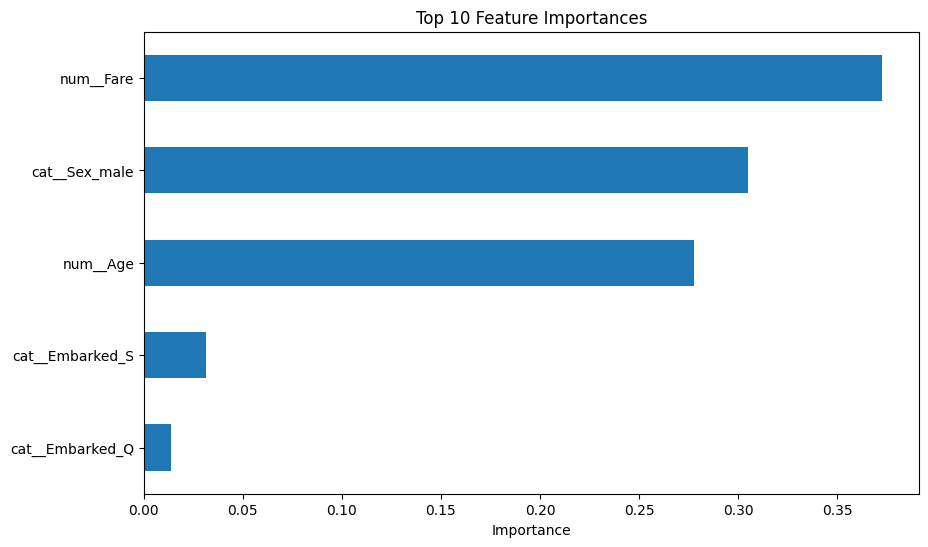

In [155]:
# 6.4 (Bonus) If RandomForest gives feature_importances_, extract and plot the top 10
# Hint: use .named_steps['preproc'] to get transformer and get_feature_names_out
import matplotlib.pyplot as plt
import pandas as pd

best_rf = grid.best_estimator_

rf_model = best_rf.named_steps['clf']

preprocessor = best_rf.named_steps['preproc']

feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(10))

plt.figure(figsize=(10,6))

importance.head(10).plot(kind='barh')

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()